# Homogeneous elastic 2-D benchmark: FD3 / OPT3 / SPECFEM2D

A flat traction-free surface, homogeneous material, identical vertical line force, receiver geometry and physical duration isolate numerical dispersion, boundary reflections and source normalization from Kirishima heterogeneity.

In [1]:
import Pkg
function find_flexopt_root(start=pwd())
    candidates = haskey(ENV, "FLEXOPT_ROOT") ? [ENV["FLEXOPT_ROOT"]] : String[]
    directory = abspath(start)
    while true
        push!(candidates, directory)
        parent = dirname(directory)
        parent == directory && break
        directory = parent
    end
    for candidate in unique(abspath.(expanduser.(candidates)))
        isfile(joinpath(candidate, "src", "flexOPT.jl")) && return candidate
    end
    error("Cannot locate flexOPT; set ENV[\"FLEXOPT_ROOT\"]")
end
flexopt_root = find_flexopt_root()
Pkg.activate(flexopt_root)
using KernelAbstractions
backend = KernelAbstractions.CPU()
makeGPUarray = identity
include(joinpath(flexopt_root, "src", "commonBatchs.jl"))
include(joinpath(flexopt_root, "src", "elasticWave2D.jl"))
include(joinpath(flexopt_root, "src", "flexOPT.jl"))
include(joinpath(flexopt_root, "src", "specfemBenchmark.jl"))
using .commonBatchs, .elasticWave2D, .flexOPT, .specfemBenchmark
# CairoMakie renders static figures inline in IJulia/VS Code and can also
# render the MP4 frames below without opening a separate GLFW window.
using CairoMakie, Statistics, LinearAlgebra
CairoMakie.activate!(type="png")
@show VERSION Threads.nthreads() Base.active_project()


  Activating 

VERSION = v"1.12.6"

project at `~/Documents/Github/flexOPT`



Threads.nthreads() = 1
Base.active_project() = "/Users/nobuaki/Documents/Github/flexOPT/Project.toml"


"/Users/nobuaki/Documents/Github/flexOPT/Project.toml"

## Common physical model and experiment

In [2]:
dx = 500.0
x = collect(-40e3:dx:40e3)
# Two void rows above z=0 keep the FD/OPT free surface away from the
# array edge, including after optStride=2 downsampling.
z = collect(-30e3:dx:1e3)
nx, nz = length(x), length(z)
vp0, vs0, rho0 = 6000.0, 3464.0, 2700.0
material = repeat(reshape(z .<= 0.0, 1, :), nx, 1)
model = (
    ρ=fill(rho0 / 1e3, nx, nz),
    Vpv=fill(vp0 / 1e3, nx, nz),
    Vsv=fill(vs0 / 1e3, nx, nz),
)
cerjanCells = 24
cerjan = CerjanBoundarySpec(
    (cerjanCells, cerjanCells),
    (cerjanCells, 0);
    damping=0.0053,
)
bcFD = boundary_geometry(material, (dx, dx); cerjan=cerjan)
sourcePosition = (x=-10e3, z=-8e3)
receiverX = [-20e3, -10e3, 0.0, 10e3, 20e3]
duration = 20.0
outputSampling = 0.05
# A three-point stencil needs a well-resolved shortest (S) wavelength.
# OPT is deliberately coarser than FD here, so it controls the source band.
optStride = 2
minimumPointsPerSWavelength = 12
coarsestSpacing = optStride * dx
sourceFrequency = vs0 /
    (minimumPointsPerSWavelength * coarsestSpacing)
sourceDelay = 1.5 / sourceFrequency
sourceForce = 1.0e10 # N/m: vertical line force in a unit-thickness slice
pointsPerSWavelength = (
    FD3=vs0 / (sourceFrequency * dx),
    OPT3=vs0 / (sourceFrequency * coarsestSpacing),
)
@assert minimum(values(pointsPerSWavelength)) >= minimumPointsPerSWavelength
@show (nx, nz) sourceFrequency sourceDelay sourceForce cerjanCells
@show pointsPerSWavelength


(nx, nz) = (161, 63)
sourceFrequency = 0.2886666666666667
sourceDelay = 5.196304849884526
sourceForce = 1.0e10
cerjanCells = 24
pointsPerSWavelength = (FD3 = 24.0, OPT3 = 12.0)


(FD3 = 24.0, OPT3 = 12.0)

## FD3: three points in space and time

In [3]:
fdConfig = ElasticThreePointConfig2D(
    pointsInSpace=3, pointsInTime=3, supplementaryOrder=2, cfl=0.38,
)
fd = prepare_elastic_wave_2d(
    model, (dx, dx);
    material_mask=material,
    boundary_conditions=bcFD,
    config=fdConfig,
)
fdCoordinates = elastic_wave_coordinates(x, z, fd)
fdPadding = fd.padding
sourcePhysical = CartesianIndex(
    argmin(abs.(x .- sourcePosition.x)),
    argmin(abs.(z .- sourcePosition.z)),
)
sourceFD = sourcePhysical + CartesianIndex(Tuple(fdPadding[1, :]))
fdSteps = ceil(Int, duration / fd.dt)
fdOutputStride = max(1, round(Int, outputSampling / fd.dt))
fdFrames = Matrix{Float32}[copy(fd.uz)]
fdTimes = Float64[0.0]
for step in 1:fdSteps
    step_elastic_wave_2d!(fd)
    elasticWave2D.add_ricker_source!(
        fd, sourceFD;
        f0=sourceFrequency, t0=sourceDelay,
        amplitude=sourceForce, component=:z, source_kind=:force,
    )
    if step % fdOutputStride == 0 || step == fdSteps
        push!(fdFrames, copy(fd.uz)); push!(fdTimes, fd.time)
    end
end
uzFD = cat(fdFrames...; dims=3)
@show fd.dt size(uzFD) maximum(abs, uzFD)


fd.dt = 0.022391716f0
size(uzFD) = (209, 87, 448)
maximum(abs, uzFD) = 0.3959874f0


0.3959874f0

## OPT3: construct volume and overlapping traction-free operators

In [4]:
ixOPT = 1:optStride:nx
izOPT = 1:optStride:nz
xOPTPhysical, zOPTPhysical = x[ixOPT], z[izOPT]
solidOPT = material[ixOPT, izOPT]
dxOPT = optStride * dx
dtOPT = 0.20 * dxOPT / (sqrt(2) * vp0)
rhoOPT = Float64.(solidOPT)
muOPT = fill(vs0^2 * (dtOPT / dxOPT)^2, size(solidOPT))
lambdaOPT = fill((vp0^2 - 2vs0^2) * (dtOPT / dxOPT)^2, size(solidOPT))
muOPT[.!solidOPT] .= 0.0
lambdaOPT[.!solidOPT] .= 0.0
optParameters = Dict{String,Any}(
    "famousEquationType" => "2DsismoTimeIsoHeteroSingleForce",
    "Δ" => (1.0, 1.0, 1.0),
    "orderBtime" => 1, "orderBspace" => 1,
    "pointsInSpace" => 3, "pointsInTime" => 3,
    "supplementaryOrder" => 2,
    "fieldItpl" => (ptsSpace=1, ptsTime=1, offsetSpace=1.0,
        offsetTime=1, YorderBspace=-1, YorderBtime=-1),
    "materItpl" => (ptsSpace=1, ptsTime=1, offsetSpace=1.0,
        offsetTime=1, YorderBspace=-1, YorderBtime=-1),
    "recipe_backend" => KernelAbstractions.CPU(),
)
optRecipe = makeOPTsemiSymbolic(optParameters)
optCerjan = CerjanBoundarySpec(
    (cld(cerjan.lower[1], optStride), cld(cerjan.lower[2], optStride)),
    (cld(cerjan.upper[1], optStride), 0);
    damping=cerjan.damping * optStride^2,
)
bcOPT = boundary_geometry(
    solidOPT, (dxOPT, dxOPT);
    free_surface_mode=:pinned_void,
    cerjan=optCerjan,
)
modelsOPT = [rhoOPT, lambdaOPT, muOPT]
pointsOPT = getModelPoints(modelsOPT[1], 3,
    optRecipe["recette"].numbersOfTheSystem.numbersOfTheSystemL.timeMarching)
familyOPT = (models=modelsOPT, modelPoints=pointsOPT,
    Δ=(1.0, 1.0, 1.0), modelName="homogeneous_OPT3")
numericalVolume = numericalOperatorConstruction(Dict{String,Any}(
    "optRec" => optRecipe, "modelFam" => familyOPT,
    "absorbingBoundaries" => nothing,
    "maskedRegionInSpace" => nothing,
    "boundaryConditions" => bcOPT,
    "representation" => "matrixfree",
))["numOperators"]
preparedVolume = prepareLinearSystem(numericalVolume;
    free_surface_spacing=(1.0, 1.0))

# Independent traction recipe σn=0, assembled additively on surface rows.
boundaryParameters = copy(optParameters)
boundaryParameters["famousEquationType"] = "elasticTractionFree2D"
boundaryRecipe = makeOPTsemiSymbolic(boundaryParameters)
normalX = zeros(size(solidOPT)); normalZ = zeros(size(solidOPT))
for (point, normal) in zip(bcOPT.free_surface.points, bcOPT.free_surface.normals)
    normalX[point], normalZ[point] = normal
end
boundaryModels = [lambdaOPT, muOPT, normalX, normalZ]
boundaryPoints = getModelPoints(boundaryModels[1], 3,
    boundaryRecipe["recette"].numbersOfTheSystem.numbersOfTheSystemL.timeMarching)
boundaryFamily = (models=boundaryModels, modelPoints=boundaryPoints,
    Δ=(1.0, 1.0, 1.0), modelName="homogeneous_free_surface")
numericalBoundary = numericalOperatorConstruction(Dict{String,Any}(
    "optRec" => boundaryRecipe, "modelFam" => boundaryFamily,
    "absorbingBoundaries" => cerjan_padding(bcOPT.cerjan),
    "maskedRegionInSpace" => bcOPT.free_surface.points,
    "representation" => "matrixfree",
))["numOperators"]
preparedBoundary = prepareLinearSystem(numericalBoundary)
surfaceWhole = numericalVolume.numericalOperators.left.geometry.freeSurfaceBoundary.points
preparedOPT = overlapBoundaryLinearSystem(
    preparedVolume, preparedBoundary, surfaceWhole;
    mode=:additive, boundary_weight=1.0,
)
@assert preparedOPT.NForceField == 2
@show preparedOPT.spaceShape length(preparedOPT.boundary_overlap_rows)


(vars, iVars) = ((ρ(x, y), λ(x, y), μ(x, y)), 1)
(vars, iVars) = ((ρ(x, y), λ(x, y), μ(x, y)), 2)
(vars, iVars) = ((ρ(x, y), λ(x, y), μ(x, y)), 3)
(vars, iVars) = ((ρ(x, y), λ(x, y), μ(x, y)), 1)
(vars, iVars) = ((ρ(x, y), λ(x, y), μ(x, y)), 2)
(vars, iVars) = ((ρ(x, y), λ(x, y), μ(x, y)), 3)
pointsIndices = availablePointsConfigurations[iConfigGeometry] = SVector{3, Int64}[[1, 1, 1] [1, 2, 1] [1, 3, 1]; [2, 1, 1] [2, 2, 1] [2, 3, 1]; [3, 1, 1] [3, 2, 1] [3, 3, 1];;; [1, 1, 2] [1, 2, 2] [1, 3, 2]; [2, 1, 2] [2, 2, 2] [2, 3, 2]; [3, 1, 2] [3, 2, 2] [3, 3, 2];;; [1, 1, 3] [1, 2, 3] [1, 3, 3]; [2, 1, 3] [2, 2, 3] [2, 3, 3]; [3, 1, 3] [3, 2, 3] [3, 3, 3]]
middleLinearν = centrePointConfigurations[iConfigGeometry] = 14
μPoints = availableμPoints[iConfigGeometry] = SVector{3, Float64}[[2.0, 2.0, 2.0];;;]
μᶜPoints = availableμᶜPoints[iConfigGeometry] = SVector{3, Float64}[[2.0, 2.0, 2.0];;;]
μaxes = availableμaxes[iConfigGeometry] = ([2.0], [2.0], [2.0])
μᶜaxes = availableμᶜaxes[iConfigGeomet

162

In [5]:
optPadding = cerjan_padding(bcOPT.cerjan)
xOPT = range(first(xOPTPhysical) - optPadding[1,1] * dxOPT;
    step=dxOPT, length=preparedOPT.spaceShape[1])
zOPT = range(first(zOPTPhysical) - optPadding[1,2] * dxOPT;
    step=dxOPT, length=preparedOPT.spaceShape[2])
sourceIXOPT = argmin(abs.(xOPTPhysical .- sourcePosition.x))
sourceIZOPT = argmin(abs.(zOPTPhysical .- sourcePosition.z))
sourceIndexOPT = CartesianIndex(
    sourceIXOPT + optPadding[1,1], sourceIZOPT + optPadding[1,2])
sourceLinearOPT = LinearIndices(preparedOPT.spaceShape)[sourceIndexOPT]
optSteps = ceil(Int, duration / dtOPT)
optOutputStride = max(1, round(Int, outputSampling / dtOPT))
sourceTimesOPT = (0:(optSteps + preparedOPT.timePointsUsedForOneStep - 2)) .* dtOPT
aOPT = @. π * sourceFrequency * (sourceTimesOPT - sourceDelay)
waveletOPT = @. (1 - 2aOPT^2) * exp(-aOPT^2)
sourceScaleOPT = sourceForce * dtOPT^2 / (rho0 * dxOPT^2)
sourceOPT = zeros(Float64, preparedOPT.NforcePoints,
    preparedOPT.NForceField, length(sourceTimesOPT))
sourceOPT[sourceLinearOPT, 2, :] .= sourceScaleOPT .* waveletOPT
propagationOPT = propagateLinearSystem(
    preparedOPT, optSteps, dtOPT;
    sourceFull=sourceOPT, output_stride=optOutputStride,
    blowup_limit=1e8,
)
@assert !propagationOPT.stopped_early
uzOPT = propagationOPT.history[:, :, 2, :]
optTimes = propagationOPT.times
@show dtOPT size(uzOPT) maximum(abs, uzOPT)


dtOPT = 0.02357022603955158
size(uzOPT) = (105, 44, 426)
maximum(abs, uzOPT) = 0.08017717724897931


0.08017717724897931

## Surface vertical-velocity traces

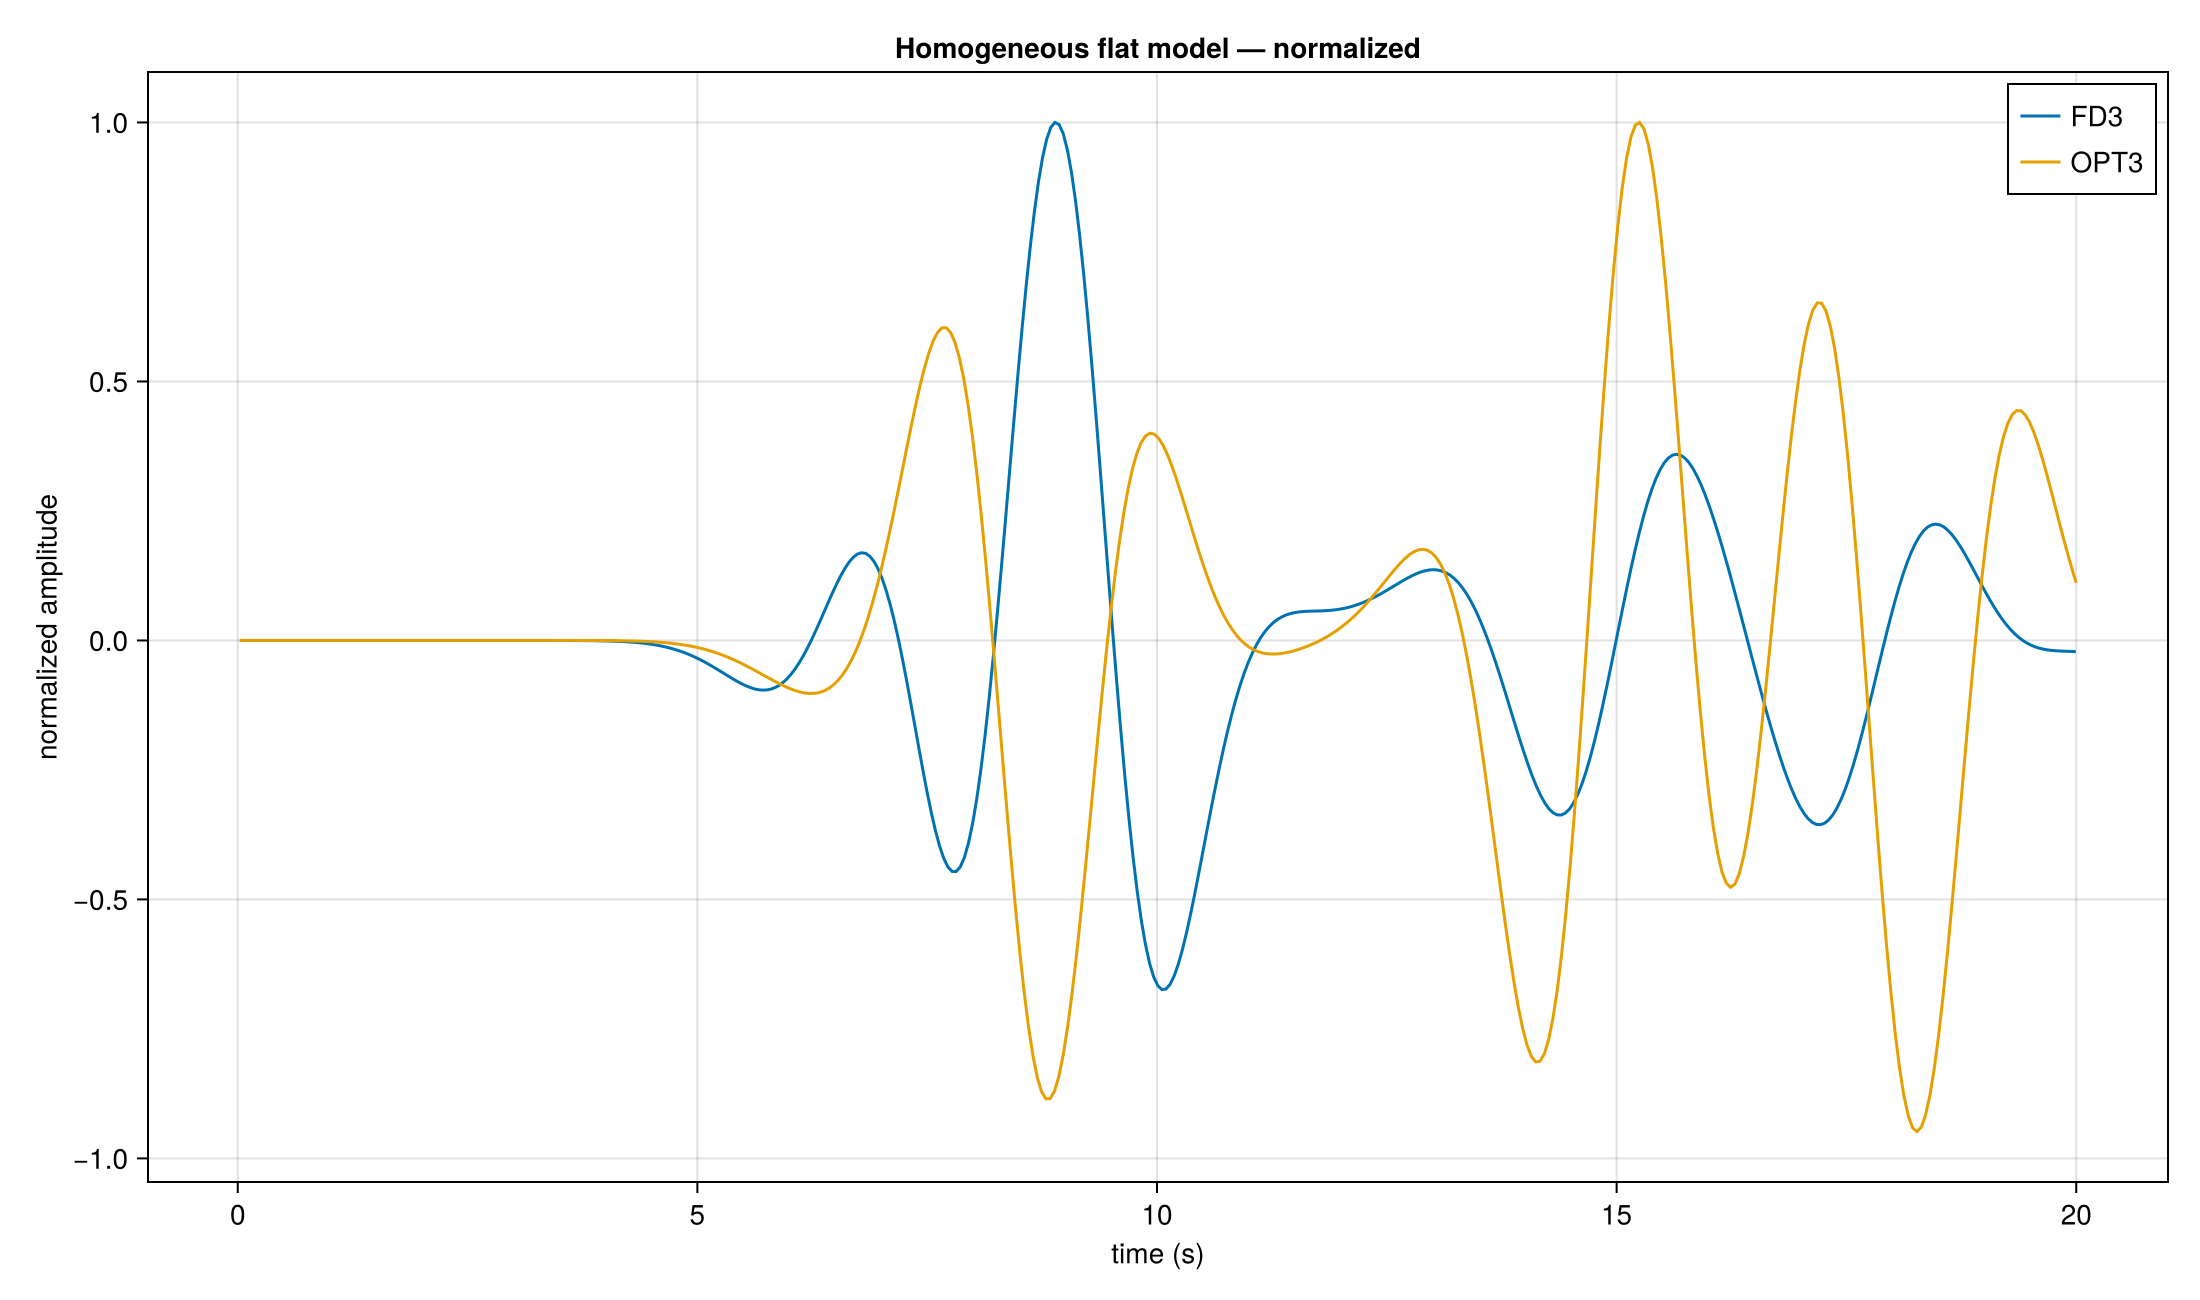

In [6]:
function velocity_traces(history, times, xaxis, zindex, receivers)
    traces = Matrix{Float64}(undef, length(times) - 1, length(receivers))
    for (j, receiver) in enumerate(receivers)
        ix = argmin(abs.(xaxis .- receiver))
        traces[:, j] .= diff(Float64.(history[ix, zindex, :])) ./ diff(times)
    end
    return (time=(times[1:end-1] .+ times[2:end]) ./ 2, values=traces)
end
fdSurfaceIndex = fdPadding[1,2] + bcFD.free_surface.points[1][2]
optSurfaceIndex = optPadding[1,2] + bcOPT.free_surface.points[1][2]
fdVelocity = velocity_traces(uzFD, fdTimes, fdCoordinates.x,
    fdSurfaceIndex, receiverX)
optVelocity = velocity_traces(uzOPT, optTimes, xOPT,
    optSurfaceIndex, receiverX)
receiver = cld(length(receiverX), 2)
fdTrace = (time=fdVelocity.time, values=fdVelocity.values[:, receiver])
optTrace = (time=optVelocity.time, values=optVelocity.values[:, receiver])
preSPECFEM = plot_solver_benchmark((FD3=fdTrace, OPT3=optTrace);
    title="Homogeneous flat model — normalized")
display(preSPECFEM.figure)
nothing


## SPECFEM2D reference

In [7]:
runSPECFEM2D = true
caseDirectory = joinpath(flexopt_root, "data", "specfem2d_benchmarks",
    "homogeneous_flat")
solidZ = findall(z .<= 0.0)
zSPECFEM = z[solidZ]
vp = fill(vp0, nx, length(solidZ))
vs = fill(vs0, nx, length(solidZ))
rho = fill(rho0, nx, length(solidZ))
dtSPECFEM = 0.15 * dx / vp0
specfemCase = prepare_specfem2d_case(
    caseDirectory, x, zSPECFEM, vp, vs, rho, zeros(nx);
    source=sourcePosition, receivers=receiverX,
    duration=duration, dt=dtSPECFEM, f0=sourceFrequency,
    source_factor=sourceForce, source_angle=0.0,
)
if runSPECFEM2D
    specfemRun = run_specfem2d_case(specfemCase.case_directory)
else
    specfemRun = (output=specfemCase.output,)
end
verticalFiles = find_specfem2d_traces(specfemRun.output; component=:z)
@assert length(verticalFiles) == length(receiverX)
specfemTraces = read_specfem2d_trace.(verticalFiles)
specfemTrace = specfemTraces[receiver]
@show specfemCase.case_directory dtSPECFEM


specfemCase.case_directory = "/Users/nobuaki/Documents/Github/flexOPT/data/specfem2d_benchmarks/homogeneous_flat"
dtSPECFEM = 0.0125


0.0125

## Shape and raw-amplitude comparison

metricsOPT.correlation = -0.4176110024674937
metricsOPT.relative_error = 0.9086259134638937
metricsSPECFEM.correlation = 0.020189706717174082
metricsSPECFEM.relative_error = 0.9997961670974113
peakVelocity = (FD3 = 0.1847695014693982, OPT3 = 0.012970712980400343, SPECFEM2D = 0.05356737971305847)
peakRatioToFD3 = (FD3 = 1.0, OPT3 = 0.07019942618911364, SPECFEM2D = 0.28991461949649944)


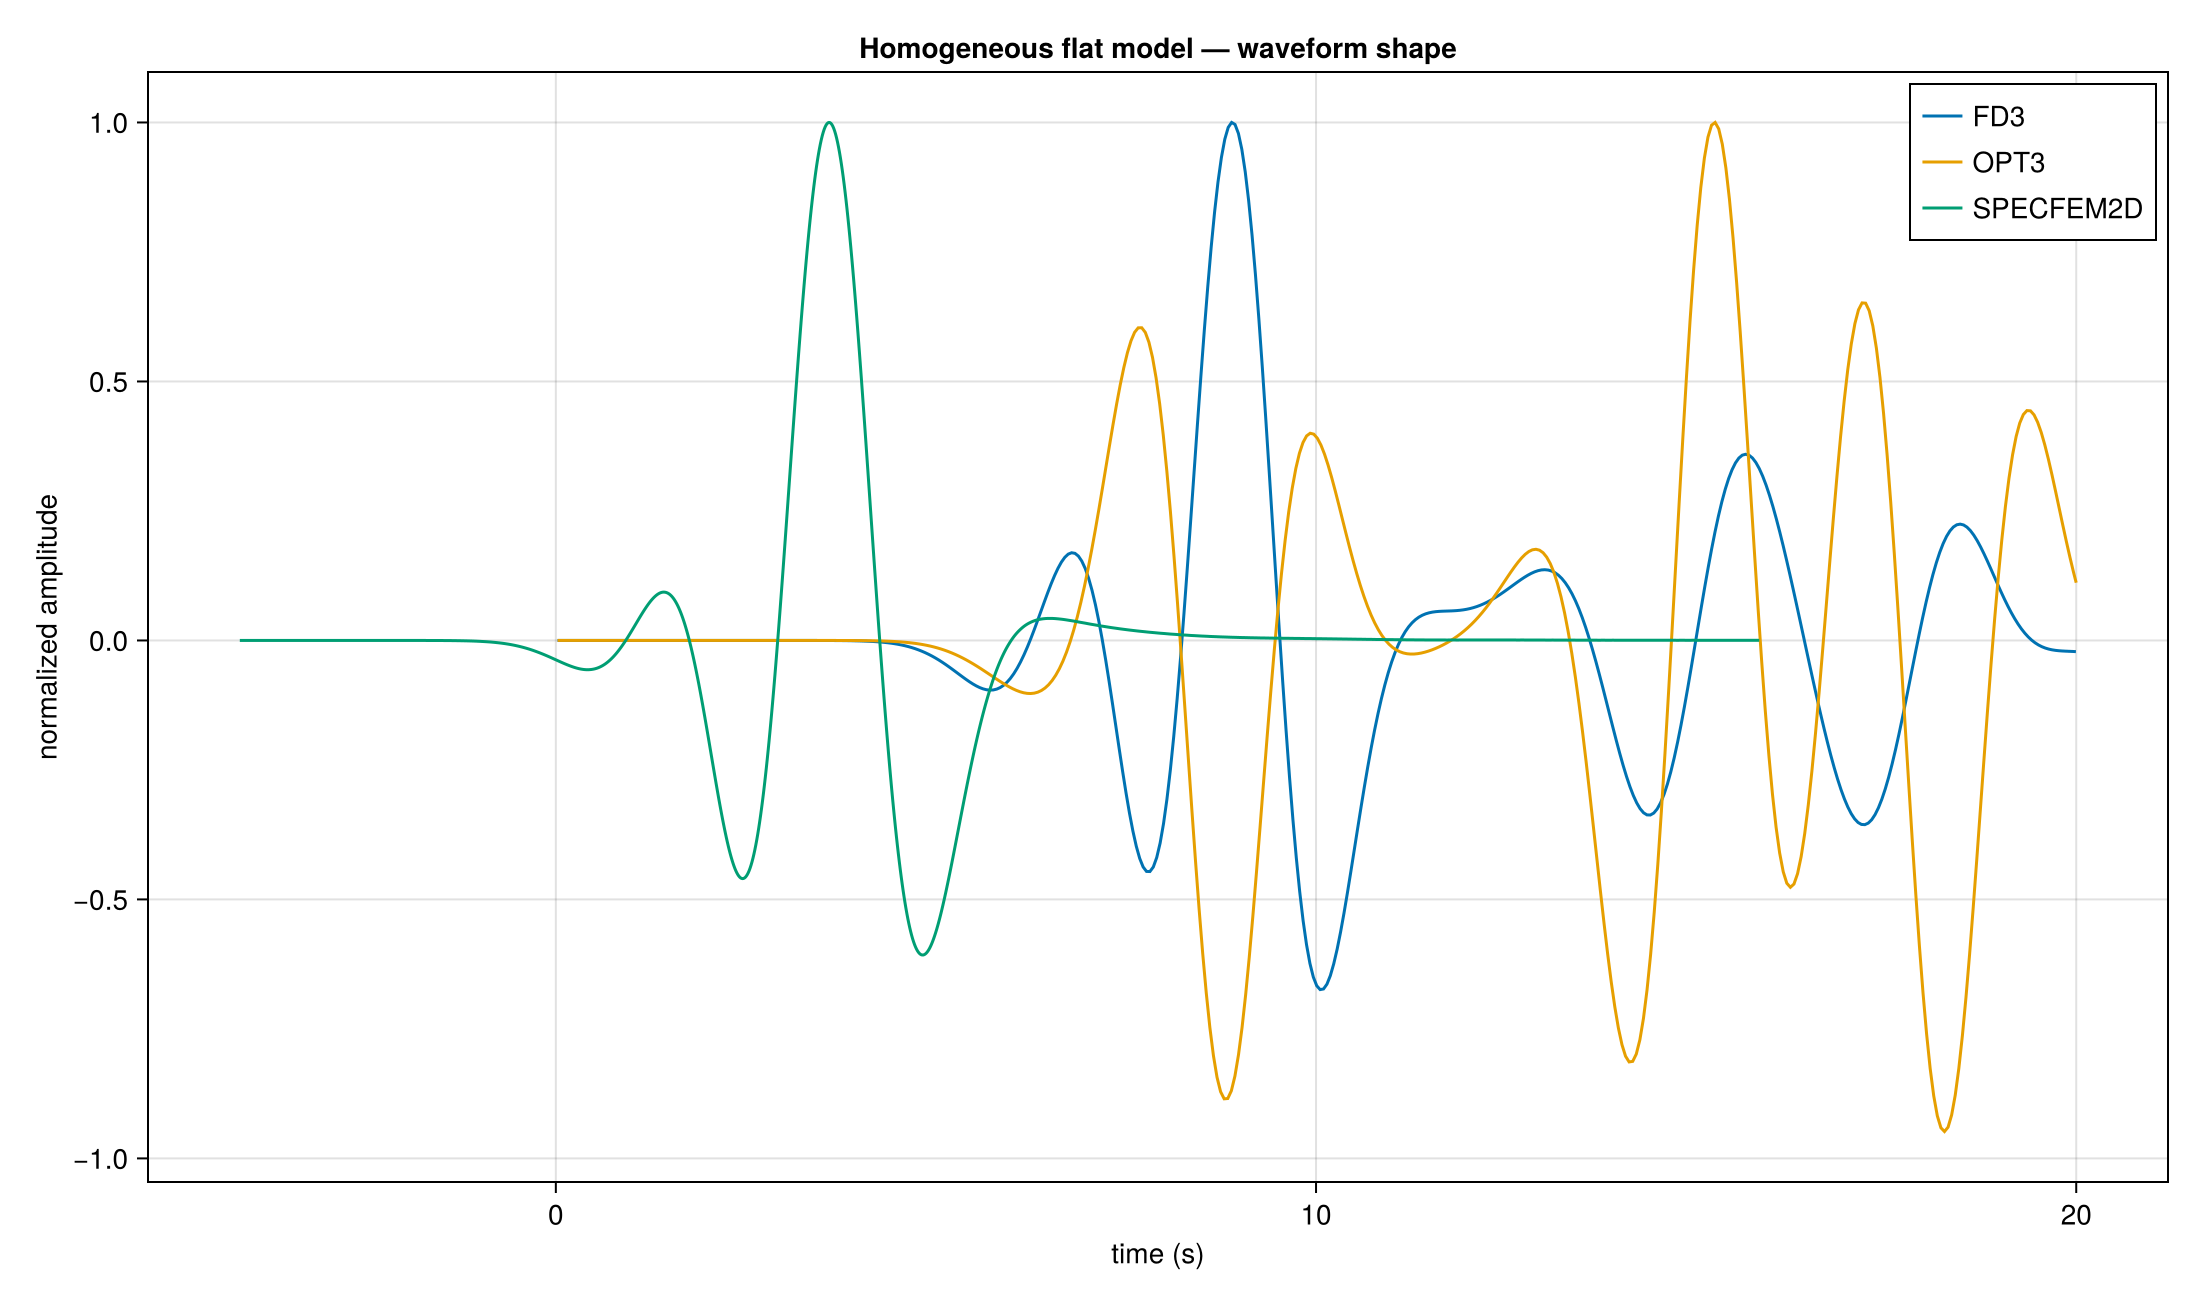

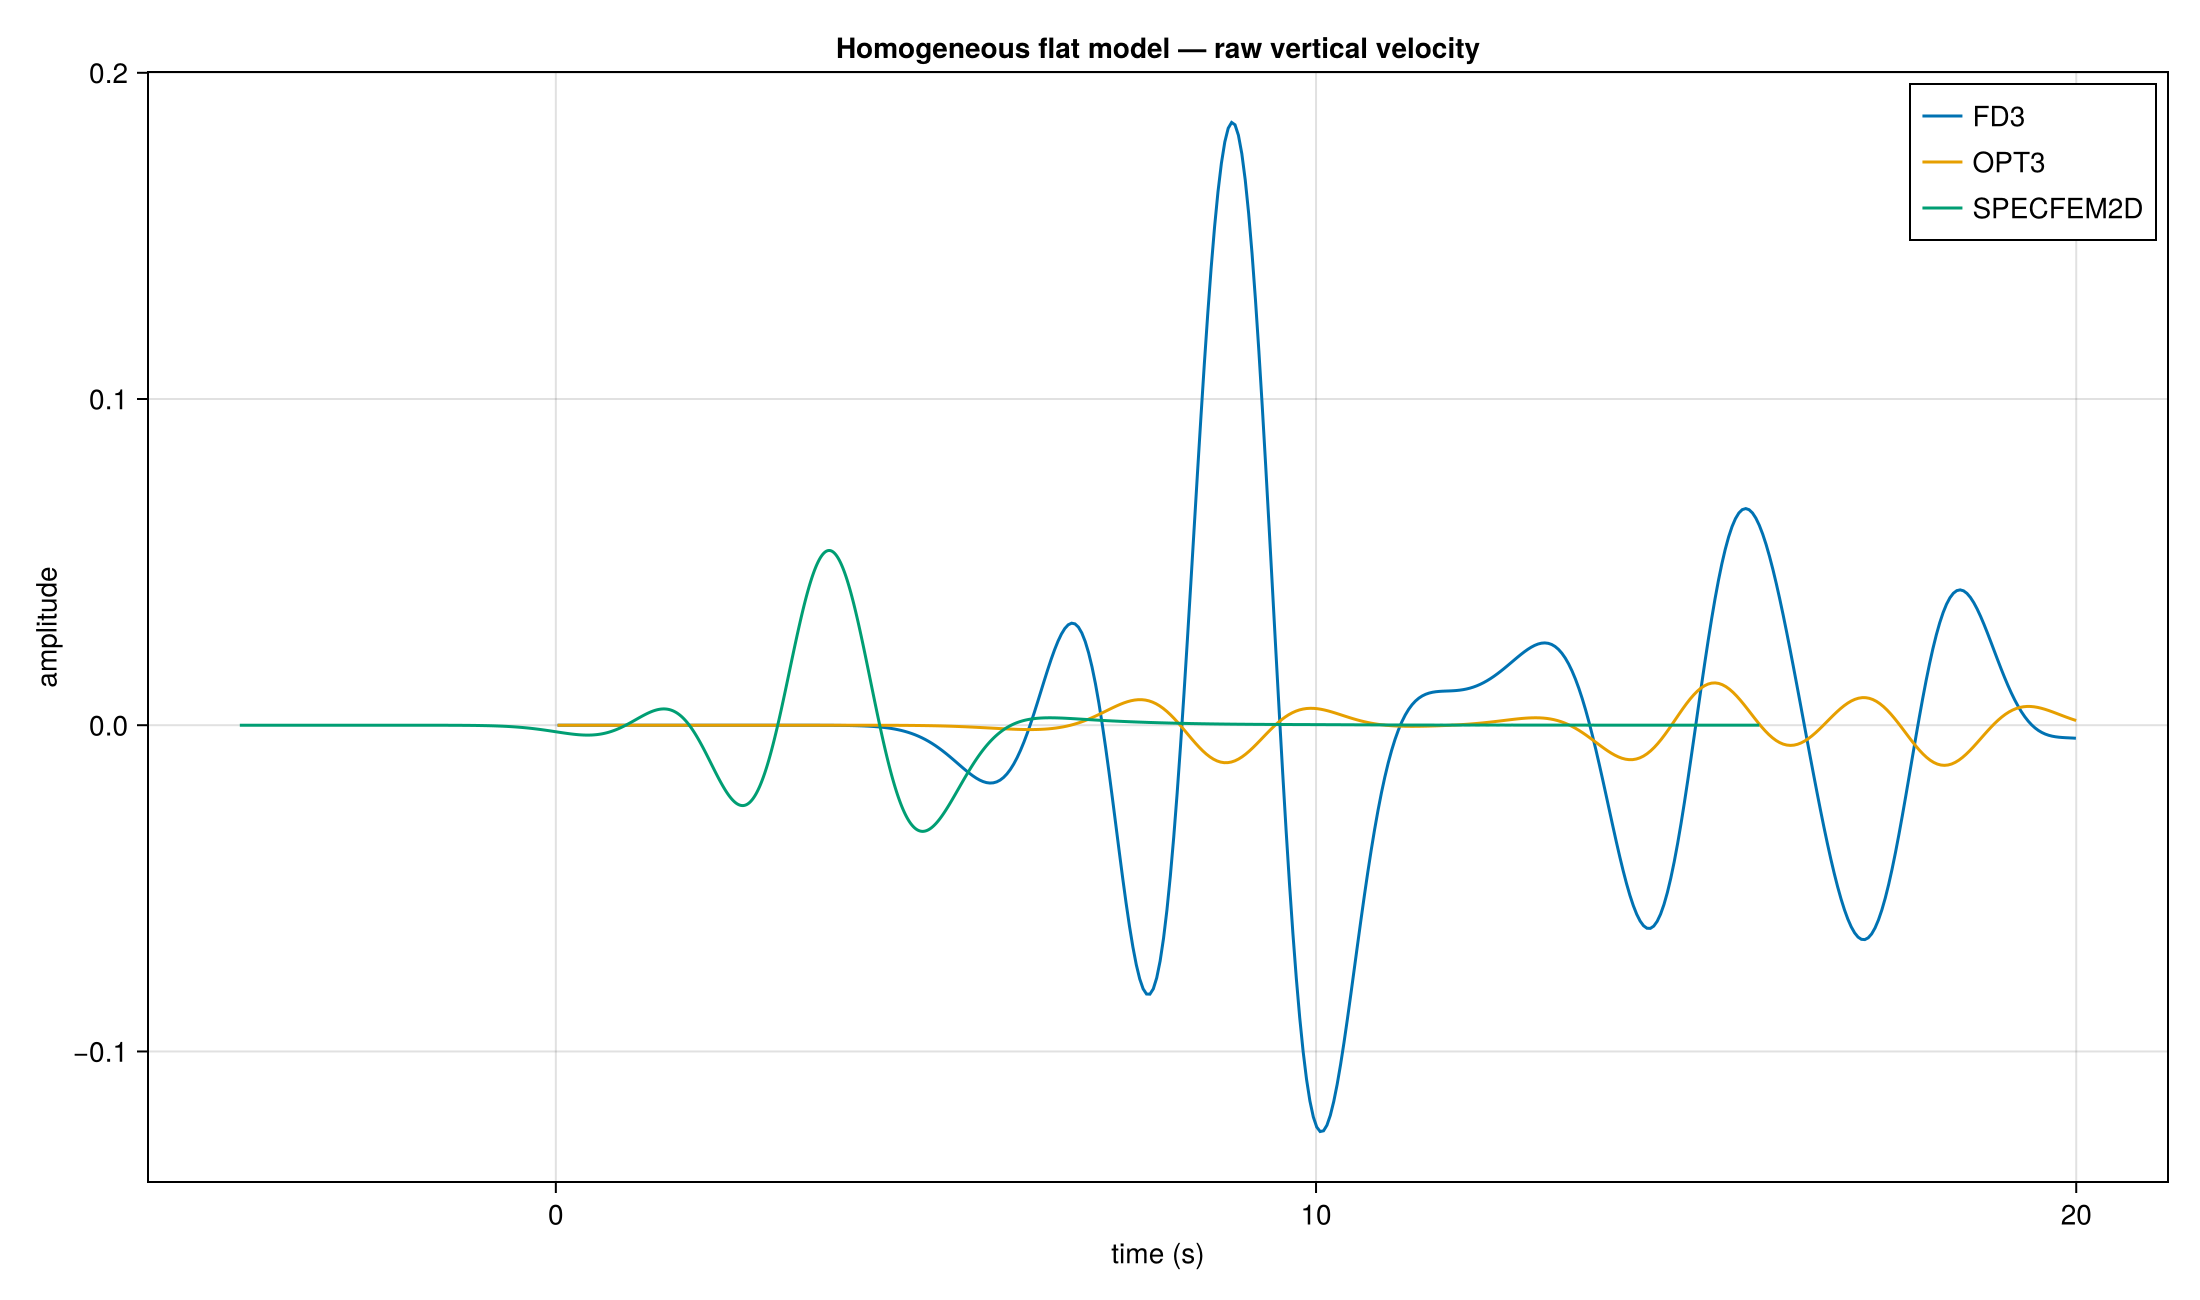

In [8]:
traces = (FD3=fdTrace, OPT3=optTrace, SPECFEM2D=specfemTrace)
metricsOPT = waveform_metrics(fdTrace, optTrace)
metricsSPECFEM = waveform_metrics(fdTrace, specfemTrace)
peakVelocity = map(trace -> maximum(abs, trace.values), traces)
peakRatioToFD3 = map(value -> value / peakVelocity.FD3, peakVelocity)
@show metricsOPT.correlation metricsOPT.relative_error
@show metricsSPECFEM.correlation metricsSPECFEM.relative_error
@show peakVelocity peakRatioToFD3
normalizedPlot = plot_solver_benchmark(traces;
    title="Homogeneous flat model — waveform shape")
rawPlot = plot_solver_benchmark(traces; normalize=false,
    title="Homogeneous flat model — raw vertical velocity")
display(normalizedPlot.figure)
display(rawPlot.figure)
nothing


## Waveforms at several surface stations

safeWindows = [(start = 5.5985779790673, stop = 11.903529167371124, direct_arrival = 7.330679595695475, first_artificial_arrival = 13.6356307839993), (start = 4.797536566589684, stop = 12.130869899923015, direct_arrival = 6.529638183217859, first_artificial_arrival = 13.862971516551191), (start = 5.5985779790673, stop = 12.289671429838835, direct_arrival = 7.330679595695475, first_artificial_arrival = 14.021773046467011), (start = 7.054313104679355, stop = 12.749795418045762, direct_arrival = 8.78641472130753, first_artificial_arrival = 14.481897034673938), (start = 8.63892813200969, stop = 13.469757246458771, direct_arrival = 10.371029748637866, first_artificial_arrival = 15.201858863086947)]


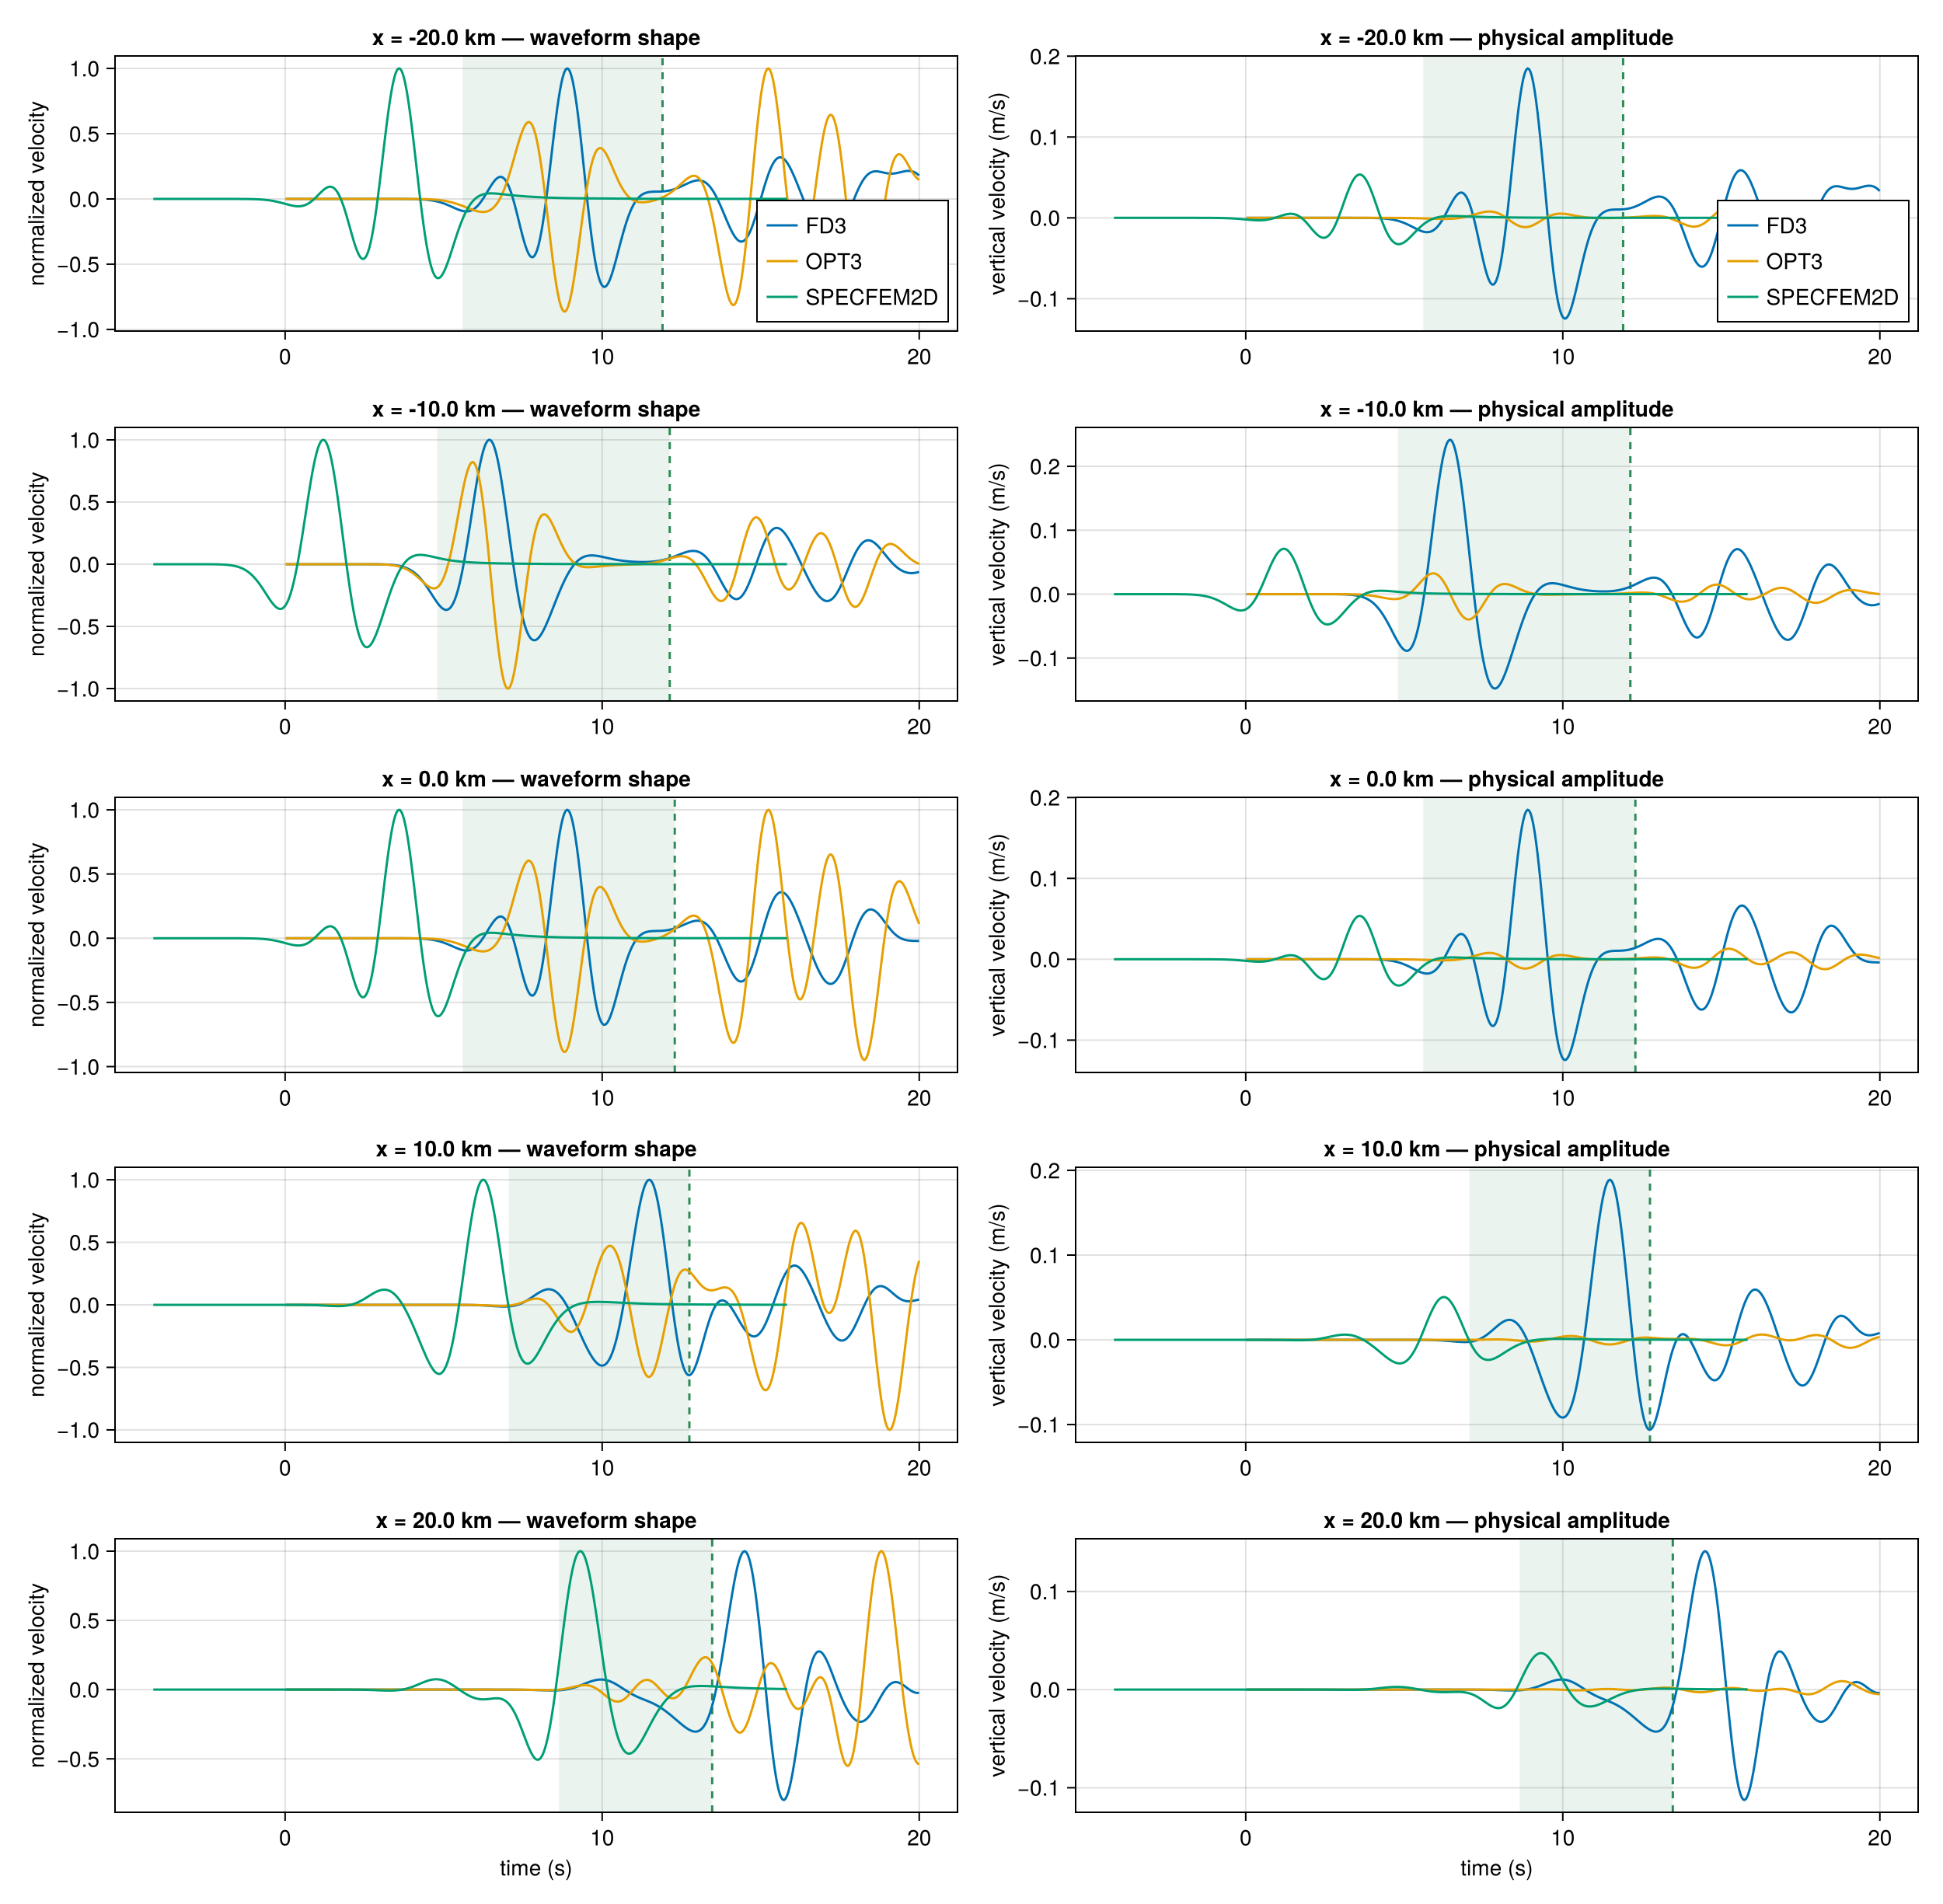

In [9]:
function artificial_boundary_windows(
    receiverX;
    source=sourcePosition,
    xmin=first(x), xmax=last(x), zmin=minimum(z[material[1, :]]),
    surface_z=0.0, velocity=vp0, source_delay=sourceDelay,
    source_frequency=sourceFrequency, duration=duration,
)
    # Image sources give the first geometrically possible P reflection from
    # each artificial boundary. The free surface z=0 is deliberately absent.
    images = (
        left=(x=2xmin - source.x, z=source.z),
        right=(x=2xmax - source.x, z=source.z),
        bottom=(x=source.x, z=2zmin - source.z),
    )
    map(receiverX) do xr
        directDistance = hypot(xr - source.x, surface_z - source.z)
        reflectedDistances = map(image ->
            hypot(xr - image.x, surface_z - image.z), images)
        directArrival = source_delay + directDistance / velocity
        artificialArrival = source_delay + minimum(reflectedDistances) / velocity
        # One half-period on each side avoids comparing only a clipped peak.
        start = max(0.0, directArrival - 0.5 / source_frequency)
        stop = min(duration, artificialArrival - 0.5 / source_frequency)
        stop > start || error("No uncontaminated time window at x=$xr")
        (start=start, stop=stop, direct_arrival=directArrival,
         first_artificial_arrival=artificialArrival)
    end
end
safeWindows = artificial_boundary_windows(receiverX)
@show safeWindows

function plot_station_waveforms(
    receiverX, fdVelocity, optVelocity, specfemTraces;
    selected=eachindex(receiverX),
    safe_windows=nothing,
)
    selected = collect(selected)
    figure = Figure(size=(1250, 245 * length(selected)))
    colors = Makie.wong_colors()
    for (row, station) in enumerate(selected)
        stationLabel = "x = $(receiverX[station] / 1e3) km"
        normalizedAxis = Axis(
            figure[row, 1];
            xlabel=row == length(selected) ? "time (s)" : "",
            ylabel="normalized velocity",
            title="$stationLabel — waveform shape",
        )
        absoluteAxis = Axis(
            figure[row, 2];
            xlabel=row == length(selected) ? "time (s)" : "",
            ylabel="vertical velocity (m/s)",
            title="$stationLabel — physical amplitude",
        )
        if !isnothing(safe_windows)
            window = safe_windows[station]
            vspan!(normalizedAxis, window.start, window.stop;
                color=(:seagreen, 0.10))
            vspan!(absoluteAxis, window.start, window.stop;
                color=(:seagreen, 0.10))
            vlines!(normalizedAxis, [window.stop]; color=:seagreen,
                linestyle=:dash, linewidth=1.5)
            vlines!(absoluteAxis, [window.stop]; color=:seagreen,
                linestyle=:dash, linewidth=1.5)
        end
        stationTraces = (
            FD3=(time=fdVelocity.time, values=fdVelocity.values[:, station]),
            OPT3=(time=optVelocity.time, values=optVelocity.values[:, station]),
            SPECFEM2D=specfemTraces[station],
        )
        for (solver, trace) in pairs(stationTraces)
            color = colors[findfirst(==(solver), keys(stationTraces))]
            peak = max(maximum(abs, trace.values), eps(Float64))
            lines!(normalizedAxis, trace.time, trace.values ./ peak;
                label=String(solver), color=color)
            lines!(absoluteAxis, trace.time, trace.values;
                label=String(solver), color=color)
        end
        row == 1 && axislegend(normalizedAxis; position=:rb)
        row == 1 && axislegend(absoluteAxis; position=:rb)
    end
    linkxaxes!(filter(!isnothing, [content(figure[r, c])
        for r in eachindex(selected), c in 1:2])...)
    return figure
end

# Change this list to show fewer or different receivers.
selectedStations = [1, 2, 3, 4, 5]
stationWaveformFigure = plot_station_waveforms(
    receiverX, fdVelocity, optVelocity, specfemTraces;
    selected=selectedStations,
    safe_windows=safeWindows,
)
display(stationWaveformFigure)
nothing


In [10]:
function crop_trace(trace, window)
    selected = findall((trace.time .>= window.start) .&
                       (trace.time .<= window.stop))
    length(selected) >= 3 || error("Too few samples in uncontaminated window")
    (time=Float64.(trace.time[selected]),
     values=Float64.(trace.values[selected]))
end

uncontaminatedMetrics = map(eachindex(receiverX)) do station
    window = safeWindows[station]
    fdStation = crop_trace(
        (time=fdVelocity.time, values=fdVelocity.values[:, station]), window)
    optStation = crop_trace(
        (time=optVelocity.time, values=optVelocity.values[:, station]), window)
    specfemStation = crop_trace(specfemTraces[station], window)
    fdOpt = waveform_metrics(fdStation, optStation)
    fdSpecfem = waveform_metrics(fdStation, specfemStation)
    (
        x_km=receiverX[station] / 1e3,
        window=(window.start, window.stop),
        FD_OPT_correlation=fdOpt.correlation,
        FD_OPT_relative_error=fdOpt.relative_error,
        FD_SPECFEM_correlation=fdSpecfem.correlation,
        FD_SPECFEM_relative_error=fdSpecfem.relative_error,
        peak_ratio_OPT_to_FD=maximum(abs, optStation.values) /
            maximum(abs, fdStation.values),
        peak_ratio_SPECFEM_to_FD=maximum(abs, specfemStation.values) /
            maximum(abs, fdStation.values),
    )
end
foreach(display, uncontaminatedMetrics)


(x_km = -20.0, window = (5.5985779790673, 11.903529167371124), FD_OPT_correlation = -0.9096100189318749, FD_OPT_relative_error = 0.41546313128694656, FD_SPECFEM_correlation = 0.06769631646182414, FD_SPECFEM_relative_error = 0.9977059730890159, peak_ratio_OPT_to_FD = 0.062124533963411076, peak_ratio_SPECFEM_to_FD = 0.04339507594699429)

(x_km = -10.0, window = (4.797536566589684, 12.130869899923015), FD_OPT_correlation = -0.0921484612483703, FD_OPT_relative_error = 0.9957452792203222, FD_SPECFEM_correlation = -0.06732866634198574, FD_SPECFEM_relative_error = 0.9977308508253163, peak_ratio_OPT_to_FD = 0.16403149495591107, peak_ratio_SPECFEM_to_FD = 0.015027842480178733)

(x_km = 0.0, window = (5.5985779790673, 12.289671429838835), FD_OPT_correlation = -0.9080713601112888, FD_OPT_relative_error = 0.41881547839786665, FD_SPECFEM_correlation = 0.06461752860432529, FD_SPECFEM_relative_error = 0.9979101036651895, peak_ratio_OPT_to_FD = 0.062124505968246604, peak_ratio_SPECFEM_to_FD = 0.04339603929882547)

(x_km = 10.0, window = (7.054313104679355, 12.749795418045762), FD_OPT_correlation = -0.8644871029517499, FD_OPT_relative_error = 0.5026549998061204, FD_SPECFEM_correlation = -0.016526077077965166, FD_SPECFEM_relative_error = 0.9998634350632156, peak_ratio_OPT_to_FD = 0.02892777504057813, peak_ratio_SPECFEM_to_FD = 0.12559959145327027)

(x_km = 20.0, window = (8.63892813200969, 13.469757246458771), FD_OPT_correlation = -0.5277300775530445, FD_OPT_relative_error = 0.8494121292081116, FD_SPECFEM_correlation = 0.32455859992134034, FD_SPECFEM_relative_error = 0.9458655904604519, peak_ratio_OPT_to_FD = 0.04703583832714419, peak_ratio_SPECFEM_to_FD = 0.8681162055462374)

## Synchronized FD3 / OPT3 propagation video

In [11]:
nearest_frame(times, time) = argmin(abs.(times .- time))

function record_wavefield_comparison(
    filepath;
    amplitude_mode=:normalized,
    video_dt=0.05,
    framerate=20,
)
    amplitude_mode in (:normalized, :absolute) ||
        error("amplitude_mode must be :normalized or :absolute")
    frameTimes = collect(0.0:video_dt:min(last(fdTimes), last(optTimes)))
    fdPeak = maximum(abs, uzFD)
    optPeak = maximum(abs, uzOPT)
    commonPeak = max(fdPeak, optPeak, eps(Float64))
    fdScale = amplitude_mode === :normalized ? max(fdPeak, eps(Float64)) : 1.0
    optScale = amplitude_mode === :normalized ? max(optPeak, eps(Float64)) : 1.0
    videoColorRange = amplitude_mode === :normalized ? (-1.0, 1.0) :
        (-commonPeak, commonPeak)
    fdFrame = Observable(Float32.(uzFD[:, :, 1] ./ fdScale))
    optFrame = Observable(Float32.(uzOPT[:, :, 1] ./ optScale))
    currentTime = Observable(0.0)
    figure = Figure(size=(1300, 620))
    titleText = amplitude_mode === :normalized ?
        "independent solver normalization" : "common absolute displacement scale"
    fdAxis = Axis(figure[1, 1]; xlabel="x (km)", ylabel="z (km)",
        title=@lift("FD3 — t = $(round($currentTime; digits=2)) s"),
        aspect=DataAspect())
    optAxis = Axis(figure[1, 2]; xlabel="x (km)", ylabel="z (km)",
        title=@lift("OPT3 — t = $(round($currentTime; digits=2)) s"),
        aspect=DataAspect())
    Label(figure[0, 1:2], "Vertical displacement: $titleText"; fontsize=22)
    fdPlot = heatmap!(fdAxis, fdCoordinates.x ./ 1e3, fdCoordinates.z ./ 1e3,
        fdFrame; colormap=:balance, colorrange=videoColorRange)
    heatmap!(optAxis, collect(xOPT) ./ 1e3, collect(zOPT) ./ 1e3,
        optFrame; colormap=:balance, colorrange=videoColorRange)
    hlines!(fdAxis, [0.0]; color=:black, linewidth=1.5)
    hlines!(optAxis, [0.0]; color=:black, linewidth=1.5)
    scatter!(fdAxis, [sourcePosition.x / 1e3], [sourcePosition.z / 1e3];
        marker=:star5, color=:gold, strokecolor=:black, markersize=18)
    scatter!(optAxis, [sourcePosition.x / 1e3], [sourcePosition.z / 1e3];
        marker=:star5, color=:gold, strokecolor=:black, markersize=18)
    Colorbar(figure[1, 3], fdPlot;
        label=amplitude_mode === :normalized ? "u_z / max|u_z|" :
            "vertical displacement u_z (m)")
    record(figure, filepath, frameTimes; framerate=framerate) do time
        currentTime[] = time
        fdFrame[] = Float32.(uzFD[:, :, nearest_frame(fdTimes, time)] ./ fdScale)
        optFrame[] = Float32.(uzOPT[:, :, nearest_frame(optTimes, time)] ./ optScale)
    end
    return filepath
end

videoDirectory = joinpath(flexopt_root, "data", "homogeneousElastic2D")
mkpath(videoDirectory)
normalizedVideo = record_wavefield_comparison(
    joinpath(videoDirectory, "FD3_OPT3_normalized.mp4");
    amplitude_mode=:normalized,
)
# Set to true when the independently normalized movie looks healthy.
makeAbsoluteVideo = true
absoluteVideo = makeAbsoluteVideo ? record_wavefield_comparison(
    joinpath(videoDirectory, "FD3_OPT3_absolute.mp4");
    amplitude_mode=:absolute,
) : nothing
@show normalizedVideo absoluteVideo
normalizedVideo


normalizedVideo = "/Users/nobuaki/Documents/Github/flexOPT/data/homogeneousElastic2D/FD3_OPT3_normalized.mp4"
absoluteVideo = "/Users/nobuaki/Documents/Github/flexOPT/data/homogeneousElastic2D/FD3_OPT3_absolute.mp4"


"/Users/nobuaki/Documents/Github/flexOPT/data/homogeneousElastic2D/FD3_OPT3_normalized.mp4"

## Interpretation

Arrival times and waveform correlation should be checked before raw amplitude. All three runs use the same nominal 2-D vertical line force, but FD mass lumping, OPT weak/source quadrature and SPECFEM GLL source projection are distinct discretizations. A stable peak ratio under grid refinement is therefore the useful absolute-amplitude test.